In [ ]:
import sys, os
from utils import * 


In [ ]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("IEEE_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "Autoencoder"
DE_LONG_RESULTS = "IEEE_CIS_all_results.pkl"
METRICS = "IEEE_CIS_metrics.pkl"


In [ ]:
# ======================================================
# ======================================================
# ======================================================
# ======================================================
# ======================================================
# =================== 4. AUTOENCODER ===================
# ======================================================
# ======================================================
# ======================================================
# ======================================================
# ======================================================

In [ ]:
# ===================== 4. AUTOENCODER =====================
AE_train_scores, AE_test_scores, AE_model = run_autoencoder(X_train, X_test, epochs=AE_EPOCHS, batch_size=AE_BATCH_SIZE)


In [ ]:
# ===================== Store metrics =====================
AE_metrics = store_anomaly_metrics(y_true=y_test, scores=-AE_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(AE_metrics)


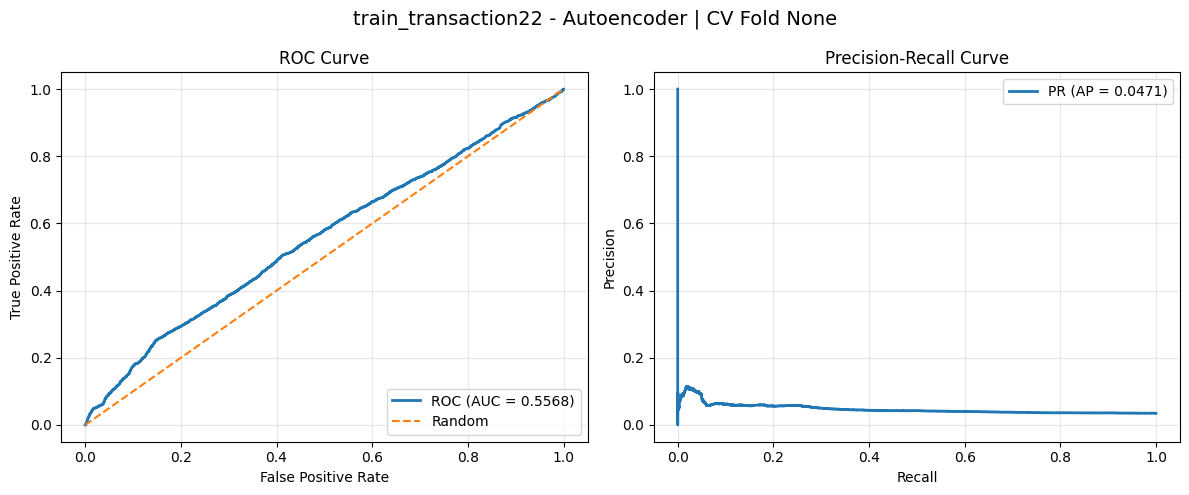

In [20]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=-AE_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)


In [ ]:
# ===================== Fit on CV folds =====================
AE_cv_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_autoencoder, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


In [ ]:
# ===================== Store CV metrics =====================

AE_cv_metrics = pd.concat([r["test_metrics"] for r in AE_cv_results], ignore_index=True)
display(AE_cv_metrics)



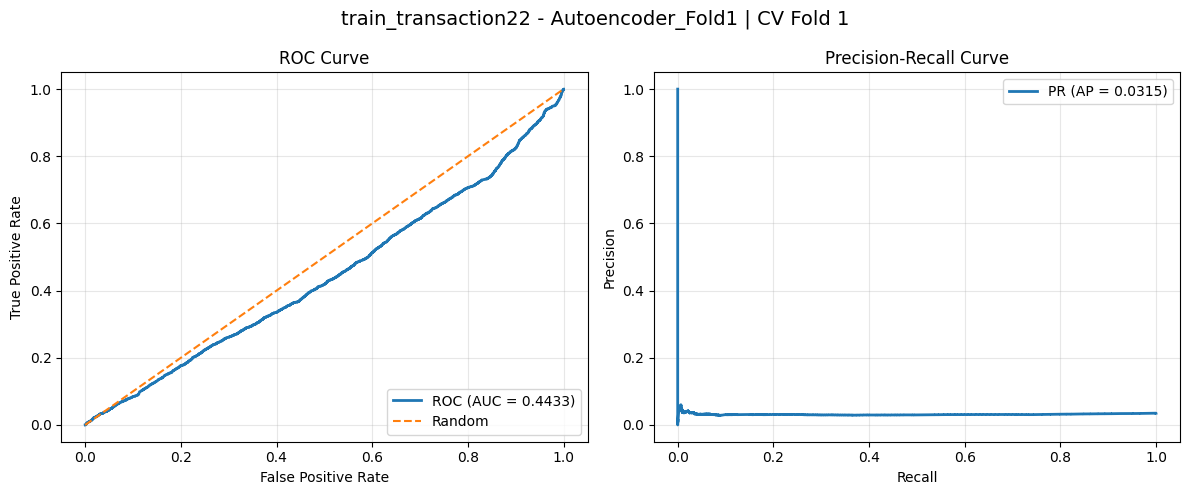

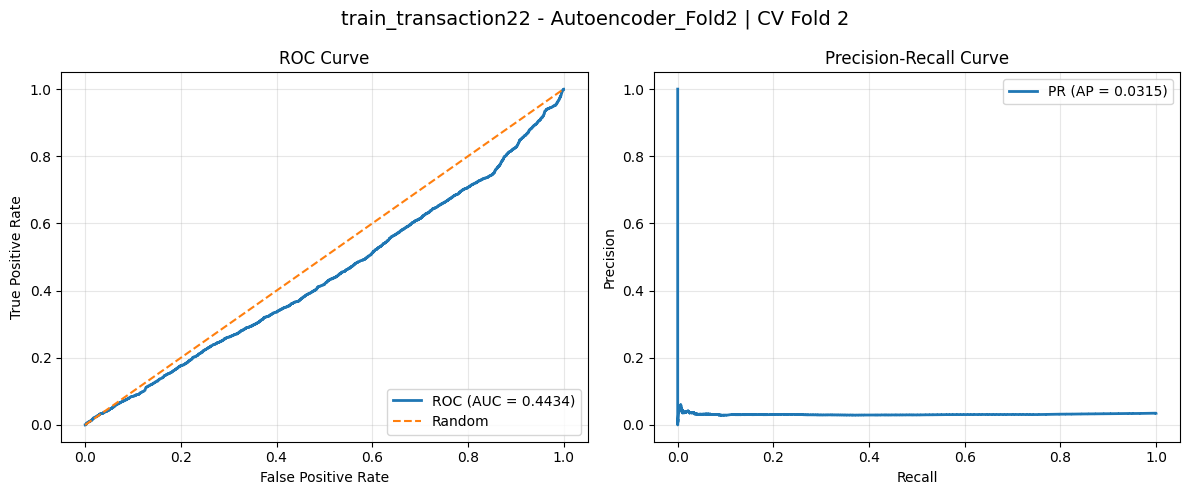

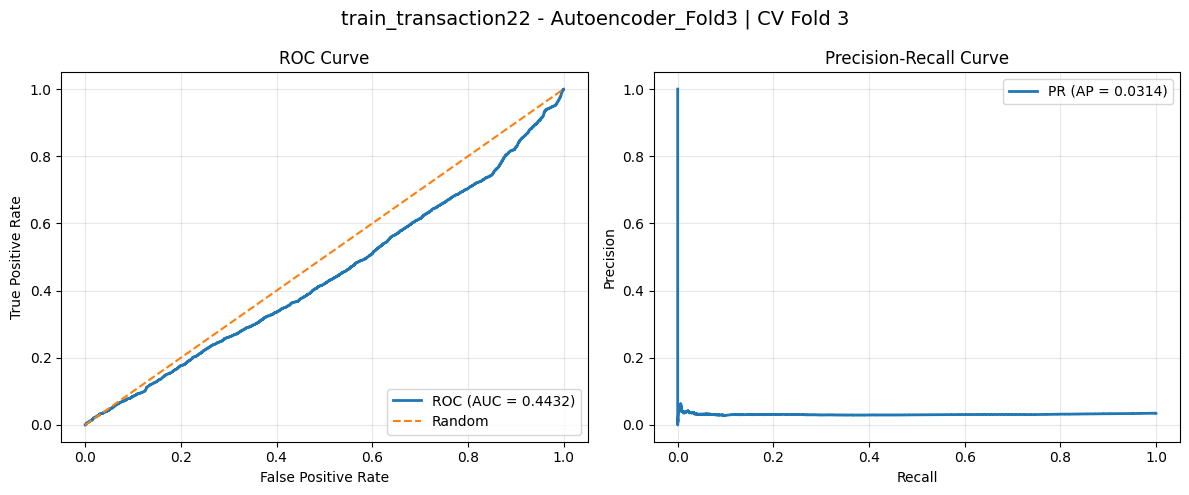

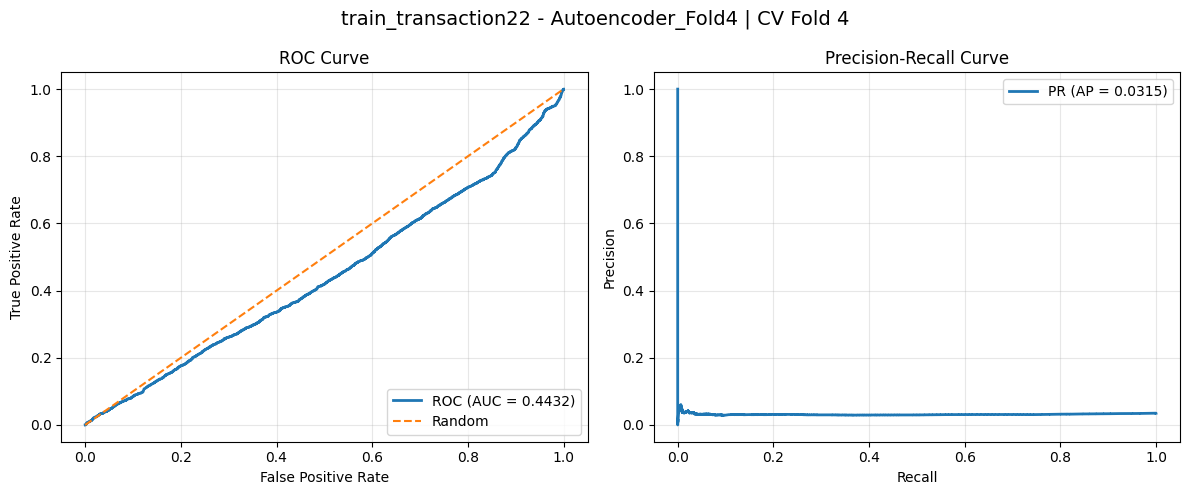

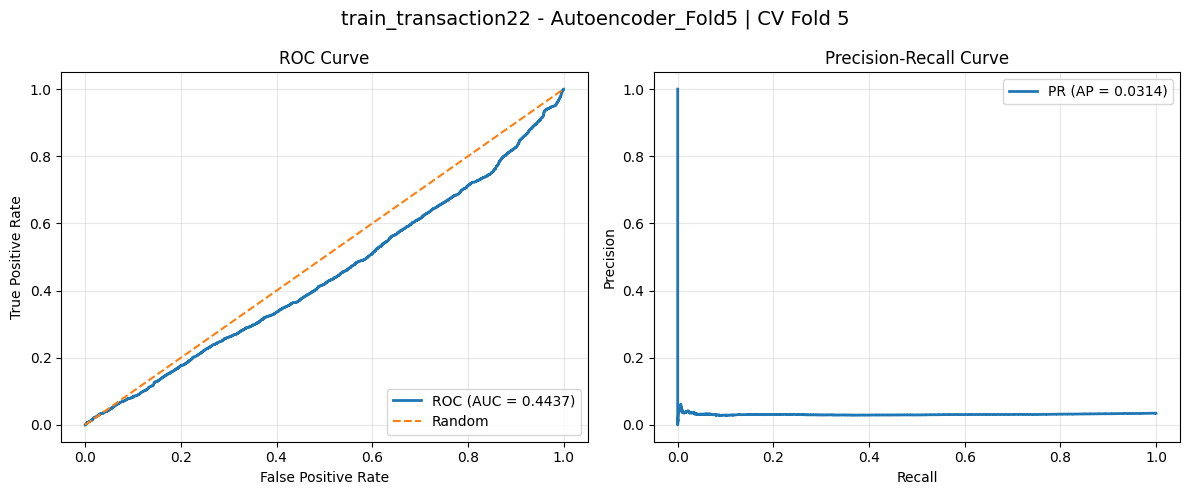

In [18]:
# ===================== Plot CV results =====================

for r in AE_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [21]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": -AE_test_scores,
    "auc": roc_auc_score(y_test, -AE_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['IEEE_CIS_all_results.pkl']

In [ ]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": AE_metrics,
    "cv_metrics": AE_cv_results
}

joblib.dump(results, METRICS)